# Multi-objective optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt.sampling_methods import LHS
from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtGPX,SmtAutoModel

from smt_optim.acquisition_strategies.multiobj import MOSEGO
from smt_optim.acquisition_functions.multi_obj import init_mpi
from smt_optim.utils.multi_obj import get_pareto_front, get_pf_from_dataset

from smt_optim.benchmarks.registry import get_problem
from smt_optim.utils.plot_2d import get_plot2d_data

from smt_optim.benchmarks.base import PymooWrapper
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


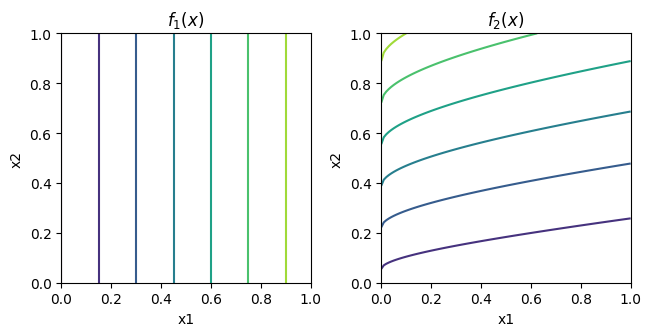

In [2]:

problem = get_problem("ZDT1")

problem.set_dim(2)

x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 1, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

fig, ax = plt.subplots(1, 2, layout="constrained")
ax[0].set_title(r"$f_1(x)$")
ax[0].contour(XX, YY, F1)
ax[1].set_title(r"$f_2(x)$")
ax[1].contour(XX, YY, F2)

for idx in range(2):
    ax[idx].set_xlabel("x1")
    ax[idx].set_ylabel("x2")
    ax[idx].set_aspect("equal")

plt.show()


In [3]:
obj_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtGPX,
)

obj_config2 = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtGPX,
)

# cstr_config = ConstraintConfig(
#     [g],
#     upper=0.,
#     surrogate=SmtAutoModel,
# )

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    # cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 6

opt_config = DriverConfig(
    max_iter = 50,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 50, "sp_method": "Cobyla"})


In [4]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              6    4.95980e+00    2.22728e+00            nan            nan            nan
             1              7    5.19837e+00    1.31310e+00              1          0.076          1.067
             2              8    6.45300e+00    0.00000e+00              1          0.064          0.928
             3              9    6.53753e+00    4.57135e-01              1          0.077          0.969
             4             10    6.53847e+00    1.75052e-01              1          0.065          1.009
             5             11    6.57085e+00    1.58399e-01              1          0.055          2.486
             6             12    6.57099e+00    1.52136e-01              1          0.064          1.663
             7             13    6.57099e+00    1.46706e-01              1          0.065          1.425
             8             14    6.57099e+00    2.13940

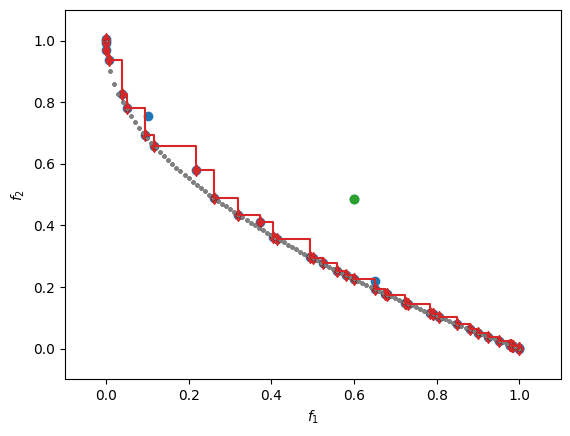

In [5]:

# ======= Optimization Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
obj_par = get_pareto_front(obj)

# ======= Solution Pareto Front =======
x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 0, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

ref_pareto = get_pareto_front(np.vstack((f1, f2)).T)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")
ax.scatter(obj_par[:, 0], obj_par[:, 1], marker="d", color="C3")

sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# PF obtained through optimization
ax.step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 1.1))
ax.set_ylim((-0.1, 1.1))

plt.show()


## Constrained multi-objective optimization

In [8]:
problem = get_problem("DTLZ5")
problem.set_dim(2)


In [9]:

obj_config = ObjectiveConfig(
    [problem.objective[0][-1]],
    type="minimize",
    surrogate=SmtGPX,
)

obj_config2 = ObjectiveConfig(
    [problem.objective[1][-1]],
    type="minimize",
    surrogate=SmtGPX,
)

cstr_config = ConstraintConfig(
    [problem.constraints[0][-1]],
    upper=0.,
    surrogate=SmtGPX,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 12

opt_config = DriverConfig(
    max_iter = 30,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 40, "sp_method": "SLSQP"})


In [10]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0             12    6.15500e-03    8.03454e-02            nan            nan            nan
             1             13    6.22752e-03    9.74799e-02              1          0.118          0.072
             2             14    6.22752e-03    9.15845e-02              1          0.157          0.061
             3             15    6.43611e-03    9.11532e-02              1          0.164          0.088
             4             16    6.43611e-03    4.97171e-02              1          0.201          0.111
             5             17    6.43611e-03    4.65390e-02              1          0.230          0.103
             6             18    6.43611e-03    1.81715e-02              1          0.205          0.174
             7             19    6.43611e-03    2.20643e-02              1          0.200          0.146
             8             20    6.56079e-03    1.77317

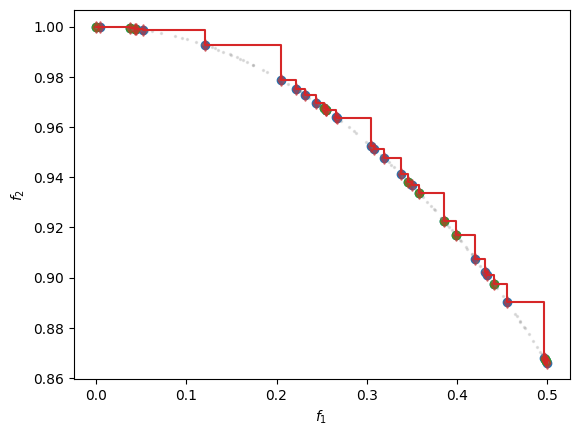

In [9]:

# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 30), seed=1)



# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

# ax.set_xlim((-0.1, 1.1))
# ax.set_ylim((-0.1, 1.1))

plt.show()

## Constrained, multi-fidelity, and multi-objective optimization

In [16]:
problem = get_problem("DTLZ5")
problem.set_dim(2)


In [83]:
obj_config = ObjectiveConfig(
    problem.objective[0],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj_config2 = ObjectiveConfig(
    problem.objective[1],
    type="minimize",
    surrogate=SmtAutoModel,
)

cstr_config = ConstraintConfig(
    problem.constraints[0],
    upper=0.,
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
    costs=[0.1, 1.],
)

nt_init = 12

opt_config = DriverConfig(
    max_iter = 1,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 20, "sp_method": "SLSQP",})

In [84]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0         14.400    8.12778e-03    1.12386e-02            nan            nan            nan
next_x = [0.91509492 0.75247679]
level(1) = [0] | [array([[9.90362483e-12, 8.61348021e-14]]), array([[1.05142270e-11, 8.71585952e-14]]), array([[9.90362482e-12, 8.60419975e-14]])]
             1         14.500    8.12778e-03    1.12386e-02              1          2.227          0.224


In [85]:
from smt_optim.acquisition_strategies.mfsego import compute_norm_sigma2_red, compute_norm_squared_cost, compute_sigma2_red


sm = state.obj_models[0].model

x = np.array([[1, 1]])
costs2 = compute_norm_squared_cost([0.1, 1.])
print(costs2)
print(sm.predict_variances_all_levels(x))
print(compute_sigma2_red(x, state.obj_models[0]))
print(compute_norm_sigma2_red(x, costs2, state.obj_models[0]))


[0.00826446 1.        ]
(array([[3.93595332e-12, 3.94259579e-12]]), [array([0.99999999])])
[[3.93595328e-12 3.94259579e-12]]
[[4.76250346e-10 3.94259579e-12]]


noise = 
[[6.47924062e-14 6.47924055e-14]
 [5.34644993e-14 5.34644987e-14]
 [8.02297559e-14 8.02297551e-14]
 [6.00967522e-14 6.00967516e-14]
 [6.42064671e-14 6.42064665e-14]
 [8.27991017e-14 8.27991008e-14]
 [3.75468970e-14 3.75468966e-14]
 [8.68225342e-14 8.68225333e-14]
 [3.90420011e-14 3.90420007e-14]
 [7.41232216e-14 7.41232208e-14]
 [9.91576447e-14 9.91576437e-14]
 [9.91504794e-14 9.91504784e-14]]
max_noise2 = 
[9.91576447e-14 9.91576437e-14]
var2 = 
[[3.89262128e-13 3.95942166e-13]
 [1.19221007e-13 1.24692499e-13]
 [4.67516189e-14 4.92906913e-14]
 [3.91473784e-13 3.97420516e-13]
 [1.72179356e-13 1.77245697e-13]
 [4.36635391e-14 4.66209691e-14]
 [2.69886747e-13 2.74919185e-13]
 [3.13343292e-14 3.55468715e-14]
 [6.67885513e-14 7.09118544e-14]
 [6.68276874e-14 6.89872872e-14]
 [3.03114351e-14 3.31626039e-14]
 [4.11149458e-14 4.59675421e-14]
 [4.89155340e-14 5.32235203e-14]
 [6.06103255e-14 6.55985046e-14]
 [7.30402865e-14 7.54353147e-14]
 [5.26153543e-13 5.32035985e-13]
 [6.21547905

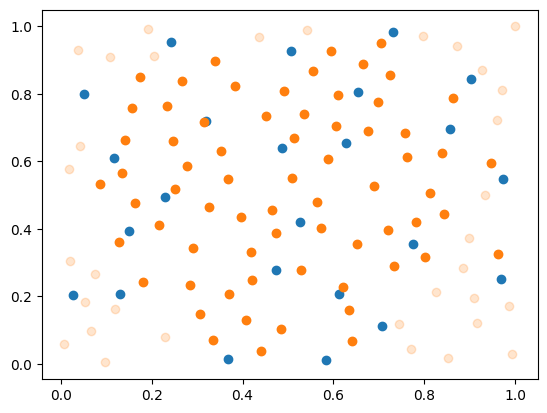

In [86]:

from smt.sampling_methods import LHS

data = state.scaled_dataset.export_as_dict()
x = data["x"]
fid_mask = data["fidelity"] == 0
x_lf = x[fid_mask, :]
x_hf = x[~fid_mask, :]

# print(sm.predict_variances_all_levels(x_lf))


noise2, rho2  = sm.predict_variances_all_levels(x_hf)
print(f"noise = \n{noise2}")

max_noise2 = np.max(noise2, axis=0)
print(f"max_noise2 = \n{max_noise2}")

sampler = LHS(xlimits=problem.bounds, criterion="ese", seed=42)
x_test = sampler(100)
x_test = np.vstack((x_test, np.array([[1, 1]])))

var2, rho2 = sm.predict_variances_all_levels(x_test)
print(f"var2 = \n{var2}")



var2_corr = var2 - max_noise2.reshape(1, -1).repeat(var2.shape[0], axis=0)
var2_corr = np.where(var2_corr < 0, 0, var2_corr)
var2_corr[:, 0] *= rho2[0]
print(f"var2_corr = \n{var2_corr}")

print(f"delta = \n{var2_corr[:, 1] - var2_corr[:, 0]}")

fig, ax = plt.subplots()

indices = var2_corr[:, 0] == 0

ax.scatter(x_lf[:, 0], x_lf[:, 1])
ax.scatter(x_test[indices, 0], x_test[indices, 1])
ax.scatter(x_test[:, 0], x_test[:, 1], color="C1", alpha=0.2)

